# Week 2: Two-View 3D Reconstruction

This notebook implements the second milestone of the CS436 project.
Building on the feature matches from Week 1, we will now:
1. Estimate the **Intrinsic Matrix (K)**.
2. Compute the **Essential Matrix (E)** and **Recover Pose (R, t)**.
3. **Triangulate** the 2D matches into a sparse 3D Point Cloud.
4. Visualize the result in both 2D and 3D.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import open3d as o3d
import os
import sys

# Add src to path
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.feature_matching import find_and_filter_matches
from src.reconstruction import (
    get_intrinsic_matrix,
    get_points_from_matches,
    reconstruct_two_views,
    save_ply,
    create_point_cloud
)

Loaded photo6.jpeg and photo10.jpeg


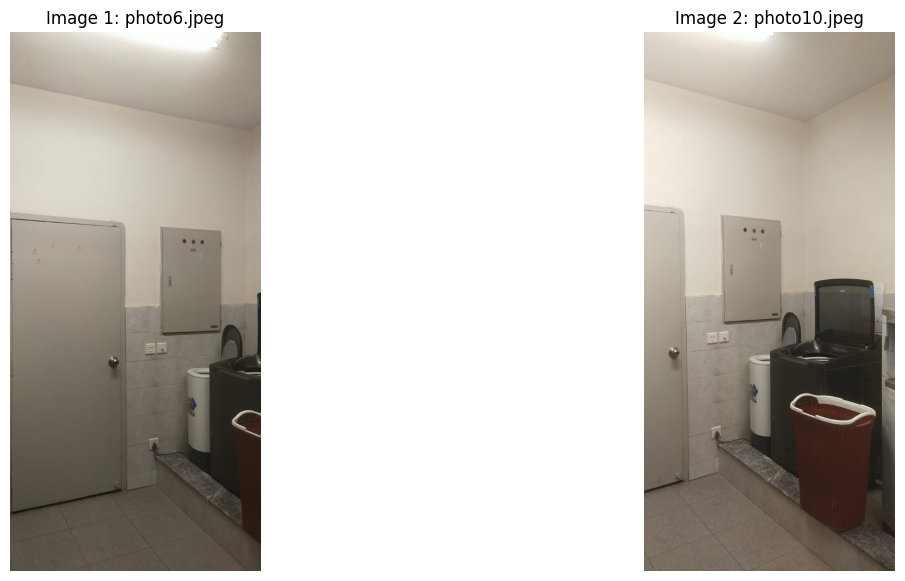

In [2]:
# Load Images 
IMG_NAME_1 = 'photo6.jpeg'  
IMG_NAME_2 = 'photo10.jpeg'

data_dir = os.path.join(module_path, 'dataset')
img1 = cv2.imread(os.path.join(data_dir, IMG_NAME_1))
img2 = cv2.imread(os.path.join(data_dir, IMG_NAME_2))

if img1 is None or img2 is None:
    print(f"Error: Could not load images from {data_dir}")
else:
    img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
    img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

    print(f"Loaded {IMG_NAME_1} and {IMG_NAME_2}")

    plt.figure(figsize=(15, 7))

    plt.subplot(1, 2, 1)
    plt.imshow(img1_rgb)
    plt.title(f"Image 1: {IMG_NAME_1}")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img2_rgb)
    plt.title(f"Image 2: {IMG_NAME_2}")
    plt.axis('off')

    plt.show()

In [3]:
# Get Feature Matches
matches, kp1, kp2, match_viz = find_and_filter_matches(img1, img2, lowe_ratio=1.0)

# convert to numpy arrays
pts1, pts2 = get_points_from_matches(matches, kp1, kp2)

print(f"Using {len(pts1)} matched points for reconstruction.")

Found 240 keypoints in img1 and 462 in img2.
Found 240 initial matches.
Filtered down to 240 good matches using Lowe's ratio test.
Using 240 matched points for reconstruction.


In [4]:
# Get Intrinsic Matrix 
K = get_intrinsic_matrix(img1.shape)
print("Intrinsic Matrix K:\n", K)

# Recover Pose and Triangulate
points_3d, R, t, pts1_inliers = reconstruct_two_views(pts1, pts2, K)

print(f"\nReconstructed {len(points_3d)} 3D points.")
print("Rotation R:\n", R)
print("Translation t:\n", t)

Intrinsic Matrix K:
 [[596.   0. 298.]
 [  0. 596. 640.]
 [  0.   0.   1.]]
Essential Matrix found. Inliers: 147 / 240

Reconstructed 147 3D points.
Rotation R:
 [[ 0.99324343  0.00488345 -0.11594668]
 [-0.0062491   0.99991529 -0.0114177 ]
 [ 0.1158811   0.01206512  0.99318981]]
Translation t:
 [[-0.98067166]
 [-0.19230133]
 [-0.03610112]]


In [5]:
# Data Processing for Visualization 

colors = []
for pt in pts1_inliers:
    x, y = int(pt[0]), int(pt[1])
    if 0 <= y < img1_rgb.shape[0] and 0 <= x < img1_rgb.shape[1]:
        colors.append(img1_rgb[y, x] / 255.0) 
    else:
        colors.append([0, 0, 0])
        
colors = np.array(colors)

# Filter out outliers
mean = np.mean(points_3d, axis=0)
std = np.std(points_3d, axis=0)
mask = (np.abs(points_3d - mean) < 3 * std).all(axis=1)

clean_points = points_3d[mask]
clean_colors = colors[mask]

print(f"Filtered {len(points_3d) - len(clean_points)} outliers.")

Filtered 4 outliers.


(np.float64(-1.2563914060592651),
 np.float64(2.9012731313705444),
 np.float64(-4.865306401252747),
 np.float64(2.004448914527893))

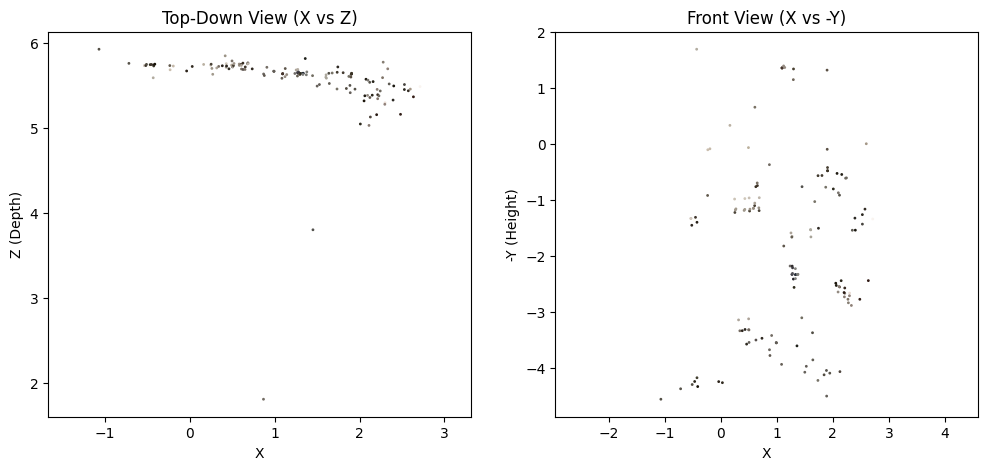

In [6]:
#  2D Scatter Plot 

plt.figure(figsize=(12, 5))

# Top-Down View 
plt.subplot(1, 2, 1)
plt.scatter(clean_points[:, 0], clean_points[:, 2], s=1, c=clean_colors)
plt.title("Top-Down View (X vs Z)")
plt.xlabel("X")
plt.ylabel("Z (Depth)")
plt.axis('equal')

# Front View 
plt.subplot(1, 2, 2)
plt.scatter(clean_points[:, 0], -clean_points[:, 1], s=1, c=clean_colors)
plt.title("Front View (X vs -Y)")
plt.xlabel("X")
plt.ylabel("-Y (Height)")
plt.axis('equal')


In [7]:
# 3D Visualization 

pcd = create_point_cloud(clean_points, clean_colors)

# Save to .ply
output_file = "reconstruction_output.ply"
o3d.io.write_point_cloud(output_file, pcd)
print(f"Saved {output_file}")

# Visualize
print("Opening 3D Visualization window...")
o3d.visualization.draw_geometries([pcd], window_name="Week 2 Reconstruction")

Saved reconstruction_output.ply
Opening 3D Visualization window...


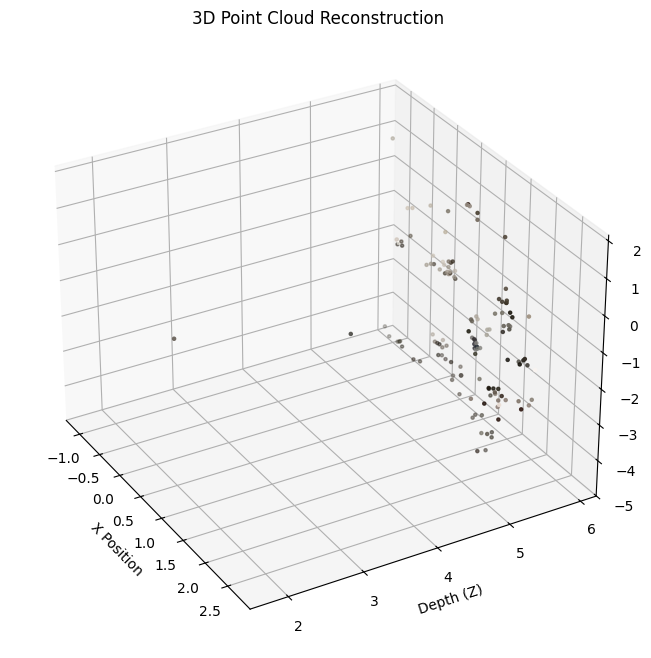

In [8]:
# Matplotlib 3D Scatter Plot 

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

xs = clean_points[:, 0]      
ys = clean_points[:, 2]     
zs = -clean_points[:, 1]     

scatter = ax.scatter(xs, ys, zs, c=clean_colors, s=5, marker='o', depthshade=True)

ax.set_xlabel('X Position')
ax.set_ylabel('Depth (Z)')
ax.set_zlabel('Height (-Y)')
ax.set_title('3D Point Cloud Reconstruction')

ax.view_init(elev=30, azim=-30)

plt.show()